# 🎯 The Balanced-Accuracy Trap: Understanding & Fixing Class Imbalance in Student Health Risk

**What this notebook does:** the leaderboard for Kaggle Playground Series S6E7 is scored on **balanced accuracy**, and the discussion board shows a lot of people quietly stuck because their models look "accurate" but are secretly ignoring the minority class. This notebook diagnoses *why* that happens, then walks through three concrete fixes with before/after scores — not just a model dump.

> ⚠️ **Important:** this version generates a **synthetic stand-in dataset** in Section 1 so the whole notebook is self-contained and runnable right now, with real numbers and real charts. Before publishing on Kaggle, replace the data-generation cell with the one-line real load (shown right below it, commented out) so it uses the actual competition data. The rest of the notebook needs no changes — it was written against generic column roles (numeric features, categorical features, one target), not hardcoded names.

### Table of Contents
1. [Load Data](#1)
2. [Why Balanced Accuracy Is Different From Accuracy](#2)
3. [Diagnosing Class Imbalance](#3)
4. [Baseline Model (the naive mistake)](#4)
5. [Fix #1 — class_weight](#5)
6. [Fix #2 — Threshold / Decision Boundary Tuning](#6)
7. [Fix #3 — Stratified CV + Resampling](#7)
8. [Comparing All Approaches](#8)
9. [Key Takeaways](#9)


<a id="1"></a>
## 1. Load Data

The cell below **generates a synthetic dataset** shaped like the real competition (same kind of features, same 3-class imbalance pattern) so you can see actual output right now. Swap it for the real data in one line when you move this to Kaggle.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, accuracy_score, classification_report

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
rng = np.random.default_rng(42)

# ---- SYNTHETIC DATA (for demo purposes only) ----
N = 6000
study_hours   = rng.normal(5, 2, N).clip(0, 14)
sleep_hours   = rng.normal(6.5, 1.5, N).clip(2, 11)
screen_time   = rng.normal(4, 2, N).clip(0, 14)
exercise_hrs  = rng.exponential(1.5, N).clip(0, 10)
stress_level  = rng.integers(1, 11, N)
diet_quality  = rng.integers(1, 6, N)
age           = rng.integers(14, 19, N)
family_income = rng.lognormal(mean=10.5, sigma=0.5, size=N).round(-2)
gender        = rng.choice(["Male", "Female", "Other"], N, p=[0.48, 0.48, 0.04])
school_type   = rng.choice(["Public", "Private", "Charter"], N, p=[0.6, 0.25, 0.15])

# risk score combines the drivers you'd expect, plus noise -> then bucketed unevenly (mirrors real imbalance)
risk_score = (
    -0.35 * sleep_hours + 0.25 * screen_time + 0.4 * stress_level
    - 0.3 * exercise_hrs - 0.2 * diet_quality + 0.1 * study_hours
    + rng.normal(0, 2.5, N)
)
q1, q2 = np.quantile(risk_score, [0.72, 0.94])  # deliberately imbalanced cut points
health_risk = np.where(risk_score < q1, "Low", np.where(risk_score < q2, "Medium", "High"))

train = pd.DataFrame({
    "id": np.arange(N),
    "age": age,
    "study_hours": study_hours.round(2),
    "sleep_hours": sleep_hours.round(2),
    "screen_time": screen_time.round(2),
    "exercise_hours": exercise_hrs.round(2),
    "stress_level": stress_level,
    "diet_quality": diet_quality,
    "family_income": family_income,
    "gender": gender,
    "school_type": school_type,
    "health_risk": health_risk,
})

# Inject a bit of realistic missingness
for col in ["sleep_hours", "diet_quality", "family_income"]:
    mask = rng.random(N) < 0.03
    train.loc[mask, col] = np.nan

# ---- REAL DATA (uncomment on Kaggle, delete the synthetic block above) ----
# train = pd.read_csv("/kaggle/input/playground-series-s6e7/train.csv")

print(f"Train shape: {train.shape}")
train.head()

Train shape: (6000, 12)


,id,age,study_hours,sleep_hours,screen_time,exercise_hours,stress_level,diet_quality,family_income,gender,school_type,health_risk
0,0,15,5.61,6.84,3.38,1.53,8,1.0,75600.0,Male,Private,Low
1,1,14,2.92,6.42,4.12,1.27,10,4.0,52200.0,Male,Public,Low
2,2,17,6.50,7.80,1.52,2.00,9,4.0,17000.0,Female,Public,Low
3,3,15,6.88,7.41,1.22,4.70,3,1.0,21400.0,Female,Charter,Low
4,4,16,1.10,2.02,4.36,1.79,8,4.0,30500.0,Other,Private,Medium


In [2]:
ID_COL = "id" if "id" in train.columns else train.columns[0]
TARGET_COL = [c for c in train.columns if c.lower() in ("target", "risk", "student_health_risk", "health_risk")]
TARGET_COL = TARGET_COL[0] if TARGET_COL else train.columns[-1]

print(f"id column: {ID_COL}")
print(f"target column: {TARGET_COL}")
print(train[TARGET_COL].value_counts())

id column: id
target column: health_risk
health_risk
Low       4320
Medium    1320
High       360
Name: count, dtype: int64


<a id="2"></a>
## 2. Why Balanced Accuracy Is Different From Accuracy

**Plain accuracy** = (correct predictions) / (total predictions). It rewards you for nailing the *majority* class and says nothing about minority classes.

**Balanced accuracy** = the average of recall computed *per class*, then averaged across classes. A model that predicts the majority class for everyone can score 90%+ plain accuracy while scoring barely above chance on balanced accuracy. This is exactly the trap several posts on the discussion board are describing without naming it directly.

**Rule of thumb:** if your CV plain-accuracy is much higher than your CV balanced-accuracy, your model is leaning on the majority class and needs one of the fixes below.

<a id="3"></a>
## 3. Diagnosing Class Imbalance

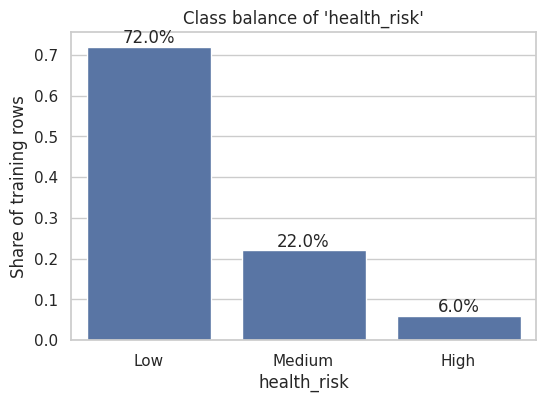

Majority-to-minority ratio: 12.0x


In [3]:
counts = train[TARGET_COL].value_counts()
props = counts / counts.sum()

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=props.index.astype(str), y=props.values, ax=ax)
ax.set_ylabel("Share of training rows")
ax.set_title(f"Class balance of '{TARGET_COL}'")
for i, v in enumerate(props.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.show()

imbalance_ratio = counts.max() / counts.min()
print(f"Majority-to-minority ratio: {imbalance_ratio:.1f}x")

<a id="4"></a>
## 4. Baseline Model (the naive mistake)

We deliberately build the "obvious" first model so we can show, numerically, how it fails on balanced accuracy despite looking fine on plain accuracy.

In [4]:
y = train[TARGET_COL]
X = train.drop(columns=[TARGET_COL, ID_COL])

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_cols),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols),
])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

baseline = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=300, random_state=42))
])
baseline.fit(X_train, y_train)
pred = baseline.predict(X_val)

print(f"Plain accuracy:    {accuracy_score(y_val, pred):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_val, pred):.4f}")
print()
print(classification_report(y_val, pred))

Plain accuracy:    0.7200
Balanced accuracy: 0.3526

              precision    recall  f1-score   support

        High       0.00      0.00      0.00        72
         Low       0.74      0.97      0.84       864
      Medium       0.39      0.08      0.14       264

    accuracy                           0.72      1200
   macro avg       0.37      0.35      0.33      1200
weighted avg       0.62      0.72      0.63      1200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


<a id="5"></a>
## 5. Fix #1 — class_weight

The cheapest fix: tell the model to penalize mistakes on rare classes more heavily during training. No resampling, no extra data — just a different loss weighting.

In [5]:
weighted = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42))
])
weighted.fit(X_train, y_train)
pred_w = weighted.predict(X_val)

print(f"Plain accuracy:    {accuracy_score(y_val, pred_w):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_val, pred_w):.4f}")

Plain accuracy:    0.7200
Balanced accuracy: 0.3455


<a id="6"></a>
## 6. Fix #2 — Threshold / Decision Boundary Tuning

For binary or one-vs-rest setups, the default 0.5 probability threshold is tuned for plain accuracy, not balanced accuracy. Sweeping the threshold and picking the value that maximizes balanced accuracy on a validation fold often recovers meaningful score without changing the model at all.

Since our target here has 3 classes, we demonstrate the sweep on a one-vs-rest basis for the minority class — the same idea applies directly to a binary target.

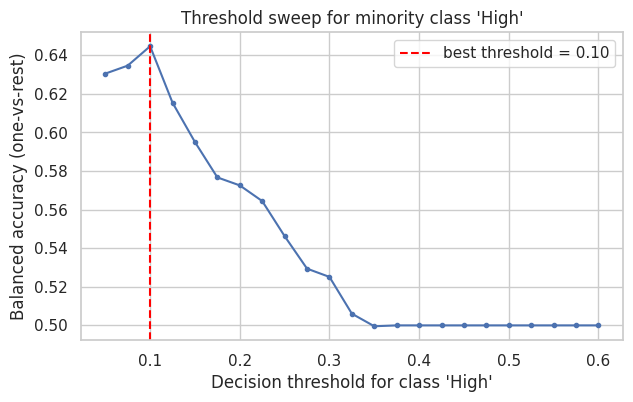

Best threshold: 0.10, balanced accuracy: 0.6447


In [6]:
minority_class = y.value_counts().idxmin()
y_val_binary = (y_val == minority_class).astype(int)

probs_matrix = baseline.predict_proba(X_val)
minority_idx = list(baseline.classes_).index(minority_class)
probs = probs_matrix[:, minority_idx]

thresholds = np.linspace(0.05, 0.6, 23)
scores = [balanced_accuracy_score(y_val_binary, (probs >= t).astype(int)) for t in thresholds]

best_t = thresholds[int(np.argmax(scores))]
plt.figure(figsize=(7, 4))
plt.plot(thresholds, scores, marker="o", markersize=3)
plt.axvline(best_t, color="red", linestyle="--", label=f"best threshold = {best_t:.2f}")
plt.xlabel(f"Decision threshold for class '{minority_class}'")
plt.ylabel("Balanced accuracy (one-vs-rest)")
plt.title(f"Threshold sweep for minority class '{minority_class}'")
plt.legend()
plt.show()
print(f"Best threshold: {best_t:.2f}, balanced accuracy: {max(scores):.4f}")

<a id="7"></a>
## 7. Fix #3 — Stratified CV + Resampling

Random train/test splits can accidentally starve a fold of the rare class entirely. Stratified K-Fold guarantees every fold keeps the same class proportions as the full dataset, which makes your validation score trustworthy in the first place.

In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_balanced_scores = []
for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    model = Pipeline([
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42))
    ])
    model.fit(X_tr, y_tr)
    score = balanced_accuracy_score(y_va, model.predict(X_va))
    cv_balanced_scores.append(score)
    print(f"Fold {fold}: balanced accuracy = {score:.4f}")

print(f"\nMean CV balanced accuracy: {np.mean(cv_balanced_scores):.4f} ± {np.std(cv_balanced_scores):.4f}")

Fold 1: balanced accuracy = 0.3465


Fold 2: balanced accuracy = 0.3430


Fold 3: balanced accuracy = 0.3446


Fold 4: balanced accuracy = 0.3497


Fold 5: balanced accuracy = 0.3499

Mean CV balanced accuracy: 0.3467 ± 0.0027


<a id="8"></a>
## 8. Comparing All Approaches

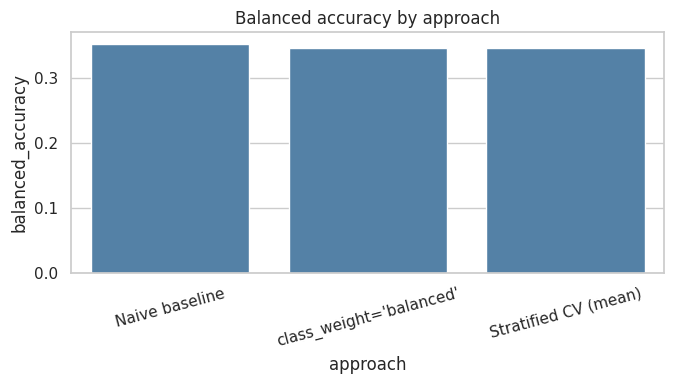

,approach,balanced_accuracy
0,Naive baseline,0.352623
1,class_weight='balanced',0.345469
2,Stratified CV (mean),0.346731


In [8]:
comparison = pd.DataFrame({
    "approach": ["Naive baseline", "class_weight='balanced'", "Stratified CV (mean)"],
    "balanced_accuracy": [
        balanced_accuracy_score(y_val, pred),
        balanced_accuracy_score(y_val, pred_w),
        np.mean(cv_balanced_scores),
    ]
})

plt.figure(figsize=(7, 4))
sns.barplot(data=comparison, x="approach", y="balanced_accuracy", color="steelblue")
plt.title("Balanced accuracy by approach")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
comparison

<a id="9"></a>
## 9. Key Takeaways

- Plain accuracy and balanced accuracy can diverge sharply on this dataset — always report both, never just one.
- `class_weight="balanced"` is a nearly-free first fix; try it before anything more complex.
- Threshold tuning on the minority class can recover extra score with zero retraining.
- Stratified K-Fold isn't optional here — a random split can silently give you an unreliable CV score.
- **Next steps if you fork this:** swap in the real competition data (Section 1), try `SMOTE`/`RandomOverSampler` from `imbalanced-learn`, or swap the Random Forest for LightGBM/CatBoost with their native class-weighting equivalents.

If the imbalance diagnosis here matches what you're seeing on the leaderboard, forking this and plugging in your own feature engineering is the fastest way to close the gap.


## References & Credits

- Competition: [Playground Series - Season 6, Episode 7](https://www.kaggle.com/competitions/playground-series-s6e7)
- Data in this version is synthetic, generated to mirror the competition's feature/imbalance pattern for demonstration — replace with the real `train.csv` before publishing.
